# TASK 2

# ENHANCED HOUSE PRICE PREDICTION

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [36]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [37]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [38]:
df = df.dropna()

In [39]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

In [41]:
x = df.drop('median_house_value', axis=1)
y = df['median_house_value'] 

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,
                                                 test_size=0.2,
                                                 random_state=42)

In [43]:
import warnings
warnings.filterwarnings('ignore')

In [44]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)
lr_model

RMSE: 70171.99539639709
R2 Score: 0.6399236679243385


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(x_train, y_train)
ridge_pred = ridge_model.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score
ridge_rmse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)
ridge_model

RMSE: 4924110268.159385
R2 Score: 0.6399235706497628


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [46]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(max_depth=4,
                               random_state=42)
dt_model.fit(x_train, y_train)
dt_pred=dt_model.predict(x_test)
 
from sklearn.metrics import mean_squared_error, r2_score
dt_rmse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)
dt_model

RMSE: 34275336271.37876
R2 Score: -1.5063899927631064


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Decision Tree'],
    'RMSE': [lr_rmse, ridge_rmse, dt_rmse],
    'R2 Score': [lr_r2, ridge_r2, dt_r2]
})

results = results.sort_values(by='R2 Score', ascending=False)

print(results)

               Model          RMSE  R2 Score
0  Linear Regression  7.017200e+04  0.639924
1   Ridge Regression  4.924110e+09  0.639924
2      Decision Tree  3.427534e+10 -1.506390


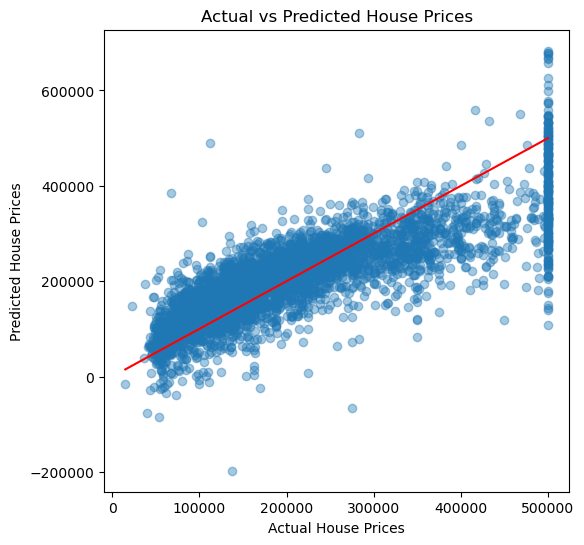

In [48]:
best_model = LinearRegression()

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [49]:
import joblib

joblib.dump(dt_model, "housing_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
